#Лабораторна робота №8

##**Тема. Структура даних граф. Алгоритми на графах**  
##**Мета**: засвоїти подання структури даних граф та головні алгоритми роботи з ними засобами Python.
##**Виконав:** Рафієв Б.

###**Завдання для самостійного розв’язання**

**Умова:** Задано зважений граф: [(1,2,5), (2,3,7), (2,4,3), (3,4,6)]. Необхідно розв’язати задачу комівояжера за допомогою алгоритму грубої сили (Brute Force), візуалізувати структуру графа та математично обґрунтувати асимптотичну складність обох методів.     
**1. Візуальна структура та аналіз графа**  
Заданий граф має 4 вершини ($1, 2, 3, 4$) та наступні зв'язки:  
- Ребро $(1,2)$ з вагою $5$
- Ребро $(2,3)$ з вагою $7$
- Ребро $(2,4)$ з вагою $3$
- Ребро $(3,4)$ з вагою $6$  
  
**2. Програмна реалізація та візуалізація на Python. Реалізація класичних алгоритмів на графах**  

--- Структура графа (Сусіди та ваги ребер) ---
Ребро (1 <-> 2) з вагою: 5
Ребро (2 <-> 1) з вагою: 5
Ребро (2 <-> 3) з вагою: 7
Ребро (2 <-> 4) з вагою: 3
Ребро (3 <-> 2) з вагою: 7
Ребро (3 <-> 4) з вагою: 6
Ребро (4 <-> 2) з вагою: 3
Ребро (4 <-> 3) з вагою: 6


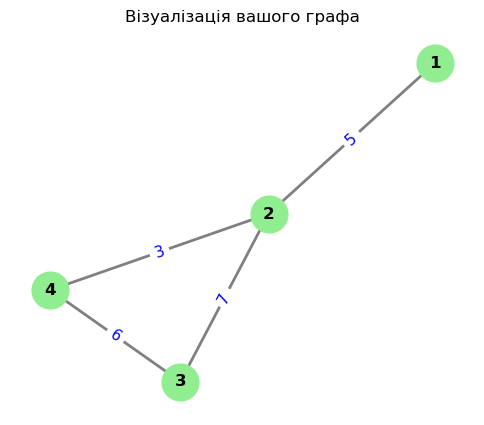


1. АЛГОРИТМ ДЕЙКСТРИ
Найкоротший шлях від 1 до 1: [1], Довжина: 0
Найкоротший шлях від 1 до 2: [1, 2], Довжина: 5
Найкоротший шлях від 1 до 4: [1, 2, 4], Довжина: 8
Найкоротший шлях від 1 до 3: [1, 2, 3], Довжина: 12

2. АЛГОРИТМ БЕЛЛМАНА-ФОРДА
Шлях від 1 до 1: [1], Довжина: 0
Шлях від 1 до 2: [1, 2], Довжина: 5
Шлях від 1 до 3: [1, 2, 3], Довжина: 12
Шлях від 1 до 4: [1, 2, 4], Довжина: 8

3. ПОШУК У ГЛИБИНУ (DFS): Всі шляхи від 1 до 4
Шлях 1: [1, 2, 3, 4]
Шлях 2: [1, 2, 4]

4. ПОШУК У ШИРИНУ (BFS): Найкоротший за кількістю кроків від 1 до 4
Найкоротший шлях (менше всього ребер): [1, 2, 4]


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

class Vertex:
    def __init__(self, key):
        self.id = key
        self.connectedTo = {}

    def addNeighbor(self, nbr, weight=0):
        self.connectedTo[nbr] = weight

    def getConnections(self):
        return self.connectedTo.keys()

    def getId(self):
        return self.id

    def getWeight(self, nbr):
        return self.connectedTo[nbr]


class Graph:
    def __init__(self):
        self.vertList = {}

    def addVertex(self, key):
        newVertex = Vertex(key)
        self.vertList[key] = newVertex
        return newVertex

    def addEdge(self, f, t, cost=0):
        if f not in self.vertList:
            self.addVertex(f)
        if t not in self.vertList:
            self.addVertex(t)
        # Для неорієнтованого графа додаємо зв'язок в обидва боки
        self.vertList[f].addNeighbor(self.vertList[t], cost)
        self.vertList[t].addNeighbor(self.vertList[f], cost)

    def __iter__(self):
        return iter(self.vertList.values())


g = Graph()
user_edges = [(1, 2, 5), (2, 3, 7), (2, 4, 3), (3, 4, 6)]

for f, t, cost in user_edges:
    g.addEdge(f, t, cost)

print("--- Структура графа (Сусіди та ваги ребер) ---")
for v in g:
    for nbr in v.getConnections():
        print(f"Ребро ({v.getId()} <-> {nbr.getId()}) з вагою: {v.getWeight(nbr)}")


G = nx.Graph()
G.add_weighted_edges_from(user_edges)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(6, 5))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightgreen")
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")
nx.draw_networkx_edges(G, pos, width=2, edge_color="gray")

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, font_color="blue")

plt.title("Візуалізація вашого графа")
plt.axis("off")
plt.show()


start_node = 1 
target_node = 4 


print("\n========================================")
print("1. АЛГОРИТМ ДЕЙКСТРИ")
print("========================================")
dijkstra_lengths, dijkstra_paths = nx.single_source_dijkstra(G, source=start_node, weight='weight')

for target in dijkstra_lengths:
    print(f"Найкоротший шлях від {start_node} до {target}: {dijkstra_paths[target]}, Довжина: {dijkstra_lengths[target]}")


print("\n========================================")
print("2. АЛГОРИТМ БЕЛЛМАНА-ФОРДА")
print("========================================")
bf_lengths = nx.single_source_bellman_ford_path_length(G, source=start_node, weight='weight')
bf_paths = nx.single_source_bellman_ford_path(G, source=start_node, weight='weight')

for target in bf_lengths:
    print(f"Шлях від {start_node} до {target}: {bf_paths[target]}, Довжина: {bf_lengths[target]}")


print("\n========================================")
print(f"3. ПОШУК У ГЛИБИНУ (DFS): Всі шляхи від {start_node} до {target_node}")
print("========================================")

def dfs_paths(graph, start, goal, path=None):
    if path is None:
        path = [start]
    if start == goal:
        yield path
    # Перебираємо невідвіданих сусідів
    for next_node in set(graph.adj[start].keys()) - set(path):
        yield from dfs_paths(graph, next_node, goal, path + [next_node])

all_dfs_paths = list(dfs_paths(G, start_node, target_node))
for idx, path in enumerate(all_dfs_paths, 1):
    print(f"Шлях {idx}: {path}")


print("\n========================================")
print(f"4. ПОШУК У ШИРИНУ (BFS): Найкоротший за кількістю кроків від {start_node} до {target_node}")
print("========================================")

def bfs_paths(graph, start, goal):
    queue = [(start, [start])]
    while queue:
        (vertex, path) = queue.pop(0)
        for next_node in set(graph.adj[vertex].keys()) - set(path):
            if next_node == goal:
                yield path + [next_node]
            else:
                queue.append((next_node, path + [next_node]))

all_bfs_paths = list(bfs_paths(G, start_node, target_node))
if all_bfs_paths:
    # Перший знайдений BFS шлях завжди має мінімальну кількість ребер
    print(f"Найкоротший шлях (менше всього ребер): {all_bfs_paths[0]}")
else:
    print("Шлях не знайдено.")

###**Висновок:** під час виконання цієї лабораторної роботи я засвоїв подання структури даних граф та головні алгоритми роботи з ними засобами Python.    
###Контрольні питання:
1. **Що таке граф у термінах теорії графів? Наведіть приклади реальних ситуацій, де можна застосовувати графи.**
   * **Граф** — це математична модель, що складається з множини вершин (вузлів) та ребер (зв'язків між ними).
   * **Приклади:** Транспортні мережі (міста та дороги), соціальні мережі (користувачі та дружба), комп'ютерні мережі (сервери та кабелі), інтернет-сайти (веб-сторінки та гіперпосилання).  

2. **Які головні види графів існують? Наведіть відмінності між орієнтованими і неорієнтованими графами.**
   * **Види графів:** Орієнтовані, неорієнтовані, зважені, ациклічні (дерева), зв'язні.
   * **Відмінність:** У неорієнтованому графі зв'язки симетричні (рух дозволено в обидва боки), а в орієнтованому графі (диграфі) кожне ребро є дугою і має чітко визначений напрямок (рух тільки за стрілкою).  

3. **Як можна подати граф у пам’яті комп’ютера? Опишіть структури даних, які використовуються для зберігання графів.**
   * **Матриця суміжності:** Двовимірний масив $V \times V$, де $1$ або вага вказує на наявність ребера. Швидка ($O(1)$), але займає багато пам'яті.
   * **Список суміжності:** Словник або масив списків, де для кожної вершини перераховані лише її сусіди. Економить пам'ять у розріджених графах.
   * **Список ребер:** Простий перелік пар/трійок вигляду `(відкуди, куди, вага)`.  

4. **Як працює алгоритм пошуку в ширину (BFS) на графах? Наведіть приклади ситуацій, де застосовується цей алгоритм.**
   * **Принцип:** Досліджує граф пошарово (радіально) за допомогою **черги (FIFO)**. Спочатку відвідує всіх найближчих сусідів, потім сусідів другого рівня і т.д.
   * **Застосування:** Пошук найкоротшого шляху в незваженому графі, індексація сторінок роботами (веб-краулінг), маршрутизація в мережах.  

5. **Що таке алгоритм пошуку в глибину (DFS) на графах? Як він відрізняється від BFS? Надайте приклади задач, де використовується DFS.**
   * **Принцип:** Рухається по одній гілці графа вглиб до упору (тупика), після чого повертається назад (backtracking). Використовує **стек або рекурсію**.
   * **Відмінність:** BFS досліджує граф рівномірно вшир (черга) і шукає найкоротший шлях, а DFS йде вглиб по одному шляху (стек).
   * **Застосування:** Пошук циклів, топологічне сортування, знаходження компонентів зв'язності, повний перебір варіантів у головоломках.  

6. **Опишіть алгоритм Дейкстри для пошуку найкоротшого шляху в графі. Які умови повинні виконуватися для успішної роботи цього алгоритму?**
   * **Опис:** Жадібний алгоритм, який на кожному кроці обирає невідвідану вершину з мінімальною поточною відстанню та оновлює (релаксує) шляхи до її сусідів.
   * **Умова:** **Ваги всіх ребер мають бути невід'ємними ($\ge 0$)**. З негативними вагами алгоритм працює некоректно.  